# Проект 01. NumPy 

## Сравнение скорости Python и NumPy

В этом задании тебе предстоит на практике сравнить скорость выполнения операций в чистом Python и с использованием NumPy.

#### Декораторы
**Декораторы** — это специальный механизм в Python, который позволяет дополнять поведение функции без изменения ее кода. Они «оборачивают» функцию в другую, добавляя нужный функционал — например, логирование, проверку прав, кеширование или измерение времени выполнения.

Синтаксически декоратор — это просто функция, которая принимает другую функцию и возвращает новую, измененную. Обычно декораторы применяются с помощью символа @ над определением функции, например:
```python
@decorator_name
def my_function():
    ...
```
Мы хотим **сравнить время выполнения функций**, реализованных на чистом Python и с использованием NumPy. Конечно, можно было бы вставить код замера времени прямо внутри каждой функции, но в этом случае код стал бы громоздким и повторяющимся, а логика замера времени смешалась бы с основной задачей.

Чтобы сделать код **более аккуратным, читаемым и удобным для повторного использования**, мы воспользуемся **декоратором**.  


#### Задание 1.1. Замер скорости
1. Реализуй декоратор `@benchmark`, который:
    * принимает функцию,
    * измеряет время ее выполнения,
    * выводит результат в **секундах**.  
2. Протестируй работу декоратора на функции `python_mean`, которая вычисляет **среднее арифметическое** элементов списка на чистом Python.
3. В качестве теста передай в функцию список из **1 000 000 элементов**.

In [2]:
import time

def benchmark(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print(f"Execution time: {end_time - start_time} seconds")
        return result
    return wrapper

In [3]:
@benchmark
def python_mean(array):
    return sum(array)/len(array)

In [4]:
array = [i for i in range(10**6)]
python_mean(array)

Execution time: 0.009570837020874023 seconds


499999.5

### Задание 1.2. Базовые функции
1. Реализуй следующие функции:
    - **Функция 1:** вычисление среднего арифметического элементов массива.
    - **Функция 2:** создание квадратной матрицы **n × n**, заполненной случайными числами.
    - **Функция 3:** проверка, есть ли в матрице **нулевые столбцы** (столбцы, где все элементы равны нулю).
    - **Функция 4:** вычисление **суммы элементов на главной диагонали** матрицы. 
2. Для каждой функции создай **два варианта реализации**:
    - на **чистом Python**,
    - с использованием **NumPy**.
3. Покажи, что **обе версии дают одинаковый результат** на одинаковых входных данных.

In [5]:
import numpy as np
import random

In [6]:
@benchmark
def numpy_mean(arr):
    arr = np.array(arr)
    return np.mean(arr)

@benchmark
def python_mean(arr):
    return sum(arr)/len(arr)

In [7]:
arr = [random.randint(-10, 10) for _ in range(1000)]

numpy_mean(arr)

Execution time: 0.0002646446228027344 seconds


np.float64(-0.007)

In [8]:
python_mean(arr)

Execution time: 0.0008318424224853516 seconds


-0.007

In [18]:
@benchmark
def numpy_create_matrix(n):
    return np.random.rand(n, n)

@benchmark
def python_create_matrix(n):
    matrix = []
    for i in range(n):
        matrix.append([random.random(), random.random(), random.random()])
    return matrix

In [19]:
C_np = numpy_create_matrix(3)
C_np

Execution time: 2.7418136596679688e-05 seconds


array([[0.04410409, 0.2728695 , 0.50829004],
       [0.94525663, 0.14533658, 0.55317658],
       [0.7864222 , 0.07298678, 0.36832489]])

In [20]:
C = python_create_matrix(3)
C

Execution time: 6.9141387939453125e-06 seconds


[[0.9711072137545247, 0.5009449031556092, 0.9846716919411911],
 [0.030614004601071443, 0.4164879659912979, 0.39006584058412197],
 [0.1103978460166879, 0.5428069378521458, 0.2839326151792072]]

In [ ]:
@benchmark
def numpy_has_zero_columns(matrix):
    # matrix = np.array(matrix)
    zero_columns_mask = (matrix == 0).all(axis=0)
    return zero_columns_mask.any()

@benchmark
def python_has_zero_columns(matrix):
    k = 0
    f = 0
    n = len(matrix)
    m = len(matrix[0])
    for j in range(m):
        for i in range(n):
            if matrix[i][j] == 0:
                f += 1
        if f == n:
            k += 1
    if k != 0:
        return True
    return False

In [54]:
numpy_has_zero_columns(C_np)

Execution time: 7.295608520507812e-05 seconds


np.False_

In [53]:
python_has_zero_columns(C_np)

Execution time: 1.239776611328125e-05 seconds


False

In [ ]:
@benchmark
def numpy_diagonal_sum(matrix):
    # matrix = np.array(matrix)
    return np.trace(matrix)

@benchmark
def python_diagonal_sum(matrix):
    n = len(matrix)
    m = len(matrix[0])
    trace = 0
    for i in range(n):
        for j in range(m):
            if i == j:
                trace += matrix[i][j]
    return trace

In [58]:
numpy_diagonal_sum(C_np)

Execution time: 5.817413330078125e-05 seconds


np.float64(0.5577655655076764)

In [59]:
python_diagonal_sum(C_np)

Execution time: 1.33514404296875e-05 seconds


np.float64(0.5577655655076764)

### Задание 1.3. Сравнение производительности Python и NumPy

Теперь, когда у тебя есть реализации функций и декоратор для измерения времени, сравни производительность Python и NumPy на практике:
1. Для каждой функции сравни время выполнения ее реализации на чистом Python и с использованием NumPy с помощью декоратора `@benchmark`.
2. Выведи результаты в удобном виде (например, в виде таблицы или форматированного текста).
3. Сделай вывод о различиях в скорости работы и объясни, за счет чего NumPy работает быстрее.

|  | _mean | _create_matrix | _has_zero_columns | _diagonal_sum |
|--|------:|---------------:| -----------------:| -------------:|
| python | 0.0008318424224853516 | 2.7418136596679688e-05 | 7.867813110351562e-06 | 5.7220458984375e-06 |
| numpy | 0.0002646446228027344 | 6.9141387939453125e-06 | 7.724761962890625e-05 | 5.984306335449219e-05 |

**Выводы:**

1. Различия в пользу функции с использованием numpy наблюдаются только в случае вычисления среднего арифметического, во всех остальных функции без numpy справляются быстрее.
2. Это связано с тем, что numpy выполняет преобразование данных для корректной работы функции.

## Головоломка судоку

**NumPy** — это мощный инструмент для работы с массивами и матрицами, который широко используется в анализе данных и научных вычислениях. Чтобы почувствовать себя увереннее при работе с матрицами, мы попробуем реализовать **решатель головоломок судоку**.

### Задание 2.1. Запрос по API
* Изучи API [YouDoSudoku](https://www.youdosudoku.com/) и разберись, как получать игры судоку и их решения.
* Напиши функцию `get_sudoku(level)`, которая принимает уровень сложности (`'easy'`, `'medium'`, `'hard'`).
* Функция должна возвращать две матрицы `numpy` размером 9×9: одну — с головоломкой, другую — с полным решением.
* После запроса выведи обе матрицы, чтобы убедиться, что данные получены и преобразованы правильно.

In [2]:
import requests
import numpy as np

API_URL = "https://youdosudoku.com/api/"
API_KEY = "AAlvvvHGgDVax8-qwz0kXUGSK6ZXVP3uLjBK8A5Wwt0"

def get_sudoku(level: str):
    if level not in ("easy", "medium", "hard"):
        raise ValueError("level must be 'easy', 'medium' or 'hard'")
    
    body = {
        "difficulty": level, # "easy", "medium", or "hard" (defaults to "easy")
        "solution": True, # True or False (defaults to True)
        "array": False # True or False (defaults to False)
    }
    
    headers = {
        "Content-Type": "application/json",
        "x-api-key": "AAlvvvHGgDVax8-qwz0kXUGSK6ZXVP3uLjBK8A5Wwt0",
    }

    response = requests.post("https://youdosudoku.com/api", json=body, headers=headers)
    data = response.json()

    puzzle_str = data["puzzle"]
    solution_str = data["solution"]

    puzzle = np.array([int(c) for c in puzzle_str]).reshape(9, 9)
    solution = np.array([int(c) for c in solution_str]).reshape(9, 9)

    return puzzle, solution

In [22]:
p, s = get_sudoku("medium")
p

array([[0, 0, 8, 6, 9, 0, 0, 0, 4],
       [0, 6, 5, 0, 0, 2, 7, 0, 0],
       [9, 2, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 5, 0, 0, 0, 4, 8],
       [5, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 4, 0, 1, 0, 0, 9, 7, 0],
       [0, 0, 0, 0, 0, 3, 0, 0, 0],
       [7, 0, 0, 4, 5, 0, 0, 6, 3],
       [4, 0, 0, 2, 8, 9, 0, 0, 0]])

In [23]:
s

array([[1, 7, 8, 6, 9, 5, 2, 3, 4],
       [3, 6, 5, 8, 4, 2, 7, 9, 1],
       [9, 2, 4, 3, 1, 7, 5, 8, 6],
       [2, 1, 9, 5, 7, 6, 3, 4, 8],
       [5, 8, 7, 9, 3, 4, 6, 1, 2],
       [6, 4, 3, 1, 2, 8, 9, 7, 5],
       [8, 5, 1, 7, 6, 3, 4, 2, 9],
       [7, 9, 2, 4, 5, 1, 8, 6, 3],
       [4, 3, 6, 2, 8, 9, 1, 5, 7]])

### Задание 2.2. Написание тестов
* Используя библиотеку `ipytest`, напиши тесты, которые проверяют корректность работы решения судоку.
* Каждый тест должен содержать [docstring](https://peps.python.org/pep-0257/), в котором кратко описано, какое правило судоку он проверяет.
* Один тест должен проверять одно правило судоку.

In [4]:
!pip install ipytest

### Задание 2.3. Реализация алгоритма решения
* Напиши алгоритм решения судоку. Можно использовать **brute-force (backtracking)**. Алгоритм должен заполнять все пустые клетки числами от 1 до 9, соблюдая правила судоку для строк, столбцов и 3×3 блоков.
* Проверь работу алгоритма с помощью ранее написанных тестов и убедись, что они покрывают все крайние случаи.
* Получи через [YouDoSudoku API](https://www.youdosudoku.com/) по 5 примеров судоку разной сложности, реши их своим алгоритмом и выведи на экран как исходные поля, так и решения. Проверь, что решения корректны.

In [65]:
import numpy as np
import ipytest
import pytest

ipytest.autoconfig()

solutions = []

def is_valid(puzzle, row, col, num):
  for x in range(9):
        if puzzle[row][x] == num:
            return False
  for y in range(9):
      if puzzle[y][col] == num:
            return False
  start_row = row - row % 3
  start_col = col - col % 3
  for i in range(3):
      for j in range(3):
          if puzzle[start_row + i][start_col + j] == num:
              return False
  return True

def solve_and_collect(puzzle):
    for i in range(9):
        for j in range(9):
            if puzzle[i][j] == 0:
                for num in range(1, 10):
                    if is_valid(puzzle, i, j, num):
                        puzzle[i][j] = num
                        solve_and_collect(puzzle)
                        puzzle[i][j] = 0
                return
    # Когда доска заполнена - копируем решение
    solutions.append(np.array([row[:] for row in puzzle]))

@pytest.fixture
def puzzle():
    p, s = get_sudoku("medium")
    return p
    

@pytest.fixture
def solution(puzzle):
    # Решаем судоку
    board = puzzle.copy().tolist()
    solutions.clear()
    solve_and_collect(board)
    return np.array(solutions[0])

In [66]:
%%ipytest

import ipytest

ipytest.autoconfig()

def test_dimension(solution):
  """
  Проверяет, что решение имеет корректный размер 9×9
  """
  assert len(solution) == 9 and len(solution[0]) == 9

def test_set_of_numbers(solution):
  """
  Проверяет, что в решении отсутствуют нули и недопустимые значения
  """
  assert set(np.sort(solution.reshape(-1))) == set([1, 2, 3, 4, 5, 6, 7, 8, 9])

def test_rows_have_unique_numbers(solution):
  """
  Проверяет, что каждая строка решения судоку содержит числа от 1 до 9 без повторений.
  """
  for row in solution:
    assert sorted(row) == list(range(1, 10))


def test_cols_have_unique_numbers(solution):
  """
  Проверяет, что каждый столбец решения судоку содержит числа от 1 до 9 без повторений.
  """
  for j in range(9):
    col = solution[:, j]
    assert sorted(col) == list(range(1, 10))

def test_blocks_have_unique_numbers(solution):
  """
  Проверяет, что каждый блок 3×3 в решении судоку содержит числа от 1 до 9 без повторений.
  """
  for block_row in range(0, 9, 3):
    for block_col in range(0, 9, 3):
      block = solution[block_row:block_row+3, block_col:block_col+3]
      flat = block.flatten()
      assert sorted(flat) == list(range(1, 10))

def test_started_puzzle_numbers(puzzle, solution):
  """
  Проверяет, что решение сохраняет все фиксированные числа исходной головоломки
  """
  mask = puzzle != 0
  assert (solution[mask] == puzzle[mask]).all()

......                                                                                       [100%]
6 passed in 6.99s


In [68]:
easy_puzzle = []
medium_puzzle = []
hard_puzzle = []
easy_solution = []
medium_solution = []
hard_solution = []

solutions = []

for i in range(5):
  p, s = get_sudoku('easy')
  easy_puzzle.append(p)
  easy_solution.append(s)

for i in range(5):
  p, s = get_sudoku('medium')
  medium_puzzle.append(p)
  medium_solution.append(s)

for i in range(5):
  p, s = get_sudoku('hard')
  hard_puzzle.append(p)
  hard_solution.append(s)

In [75]:
for i in range(5):
  solve_and_collect(easy_puzzle[i])

for i in range(5):
  print(solutions[i] == easy_solution[i])

[[ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  Tru

In [77]:
solutions = []

for i in range(5):
  solve_and_collect(medium_puzzle[i])

for i in range(5):
  print(solutions[i] == medium_solution[i])

[[ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  Tru

In [78]:
solutions = []

for i in range(5):
  solve_and_collect(hard_puzzle[i])

for i in range(5):
  print(solutions[i] == hard_solution[i])

[[ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]]
[[ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  Tru

## Сингулярное разложение (SVD)

В библиотеке NumPy реализовано множество полезных математических функций: операции с массивами, линейная алгебра, вычисление статистических показателей, тригонометрические и экспоненциальные функции, преобразования Фурье, решение систем уравнений, а также **сингулярное разложение матриц**.

Любую матрицу (A) можно разложить следующим образом:

$$A = U \times S \times V^T$$

Где:
* $U$ — матрица **левых сингулярных векторов**;
* $S$ — **диагональная матрица сингулярных чисел**;
* $V^T$ — матрица **правых сингулярных векторов** (транспонированная).

Это разложение называется **сингулярное разложение**, и оно широко используется в **анализе данных** и **машинном обучении**:

* **сжатие изображений** и сигналов;
* **рекомендательные системы** (например, в коллаборативной фильтрации);
* **выделение основных компонентов** (PCA);
* **аппроксимация матриц** и уменьшение размерности;
* в задачах **анализ текста** (Latent Semantic Analysis).

Матрица $S$ содержит **сингулярные числа**, которые несут основную информацию о матрице (например, изображении).

Если сохранить только **k наибольших сингулярных чисел**, мы можем получить приближенную матрицу:

$$A_k = U[:, :k] \times S[:k, :k] \times V^T[:k, :]$$

* Это позволяет **сжимать изображения**, сохраняя ключевую информацию и убирая шум.
* Чем меньше (k), тем сильнее сжатие, но при этом может теряться часть деталей.

В этом проекте мы воспользуемся SVD для сжатия изображений, чтобы на практике увидеть, как сохраняются важные признаки картинки при уменьшении ее размерности.

### Задание 3.1. Подготовка изображения и SVD-разложение
1. С помощью библиотеки `Pillow` загрузи изображение [jackal.png](../misc/jackal.png).
<center><img src="../misc/jackal.png" alt="jackal" width="200" height="200"></center>

2. Преобразуй изображение в `np.array`.
3. Примени **SVD-разложение** к массиву с помощью `np.linalg.svd`.
4. Выведи размерность изображения и матриц $U$, $S$, $V$.


In [79]:
!pip install pillow

In [93]:
from PIL import Image

img = np.array(Image.open('..\misc\jackal.png'))
img.shape

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\TEMP\ipykernel_12888\1751073351.py:3: SyntaxWarning: invalid escape sequence '\m'
  img = np.array(Image.open('..\misc\jackal.png'))


(854, 803, 4)

In [101]:
U, S, V = np.linalg.svd(img[:, :, 0], full_matrices=False) # данные параметры даны тут, чтобы избежать недостатка памяти
U.shape

(854, 803)

In [102]:
V.shape

(803, 803)

In [103]:
S.shape

(803,)

### Задание 3.2. Сжатие изображения и визуализация результатов
1. Определи набор значений (k) — количество сингулярных чисел для сохранения. Рекомендуемые значения: [100, 50, 25, 20, 10].
2. Для каждого (k) создай **приближенную версию изображения**:
   $$A_k = U[:, :k] \times S[:k, :k] \times V^T[:k, :]$$
3. Визуализируй результаты:
   * Размести **оригинальное изображение** в первом subplot'е.
   * Размести все сжатые версии в остальных subplot'ах.
   * Добавь **заголовки**, указывающие значение (k).

<center><img src="../misc/jackals.png" alt="jackal" width="400" height="300"></center>

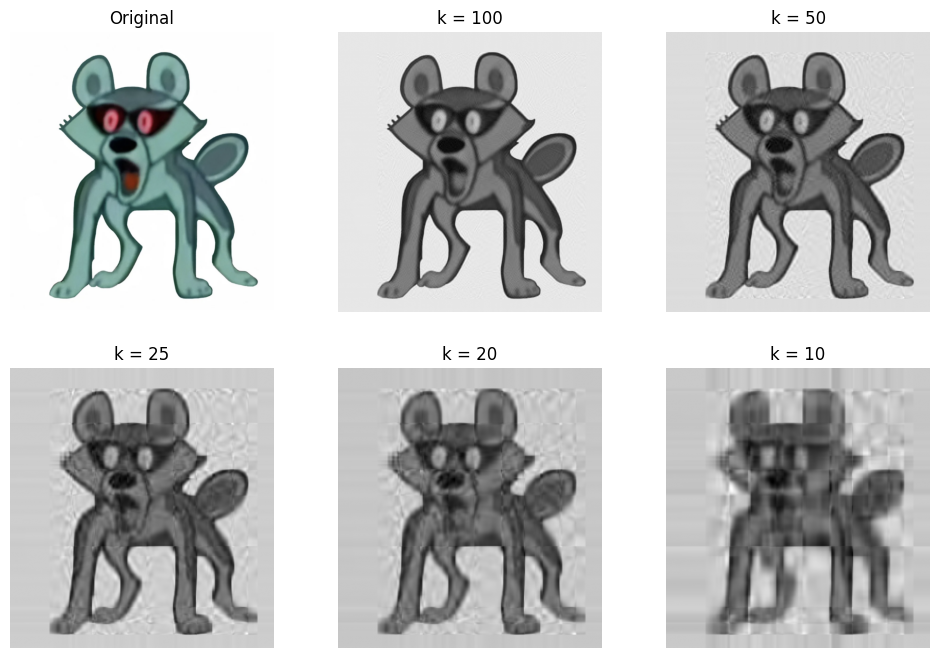

In [105]:
import matplotlib.pyplot as plt
k = [100, 50, 25, 20, 10]

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

for idx, i in enumerate(k, start=2):
    Uk = U[:, :i]
    Sk = np.diag(S[:i])
    Vk = V[:i, :]

    Ak = Uk @ Sk @ Vk

    plt.subplot(2, 3, idx)
    plt.imshow(Ak, cmap='gray')
    plt.title(f"k = {i}")
    plt.axis('off')

plt.show()
